# Regression analysis

In [2]:
import re
import os
import pandas as pd
import plotnine as pln
from statsmodels.formula.api import ols

In [5]:
data = pd.read_csv('../data/viral/metadata/SARS2_BA1_SPIKE_Dadonaite.csv')
data

,ID,mutant,num_mutations,target,sequence
0,SARS2_BA1_M1I,M1I,1,-2.2303,IFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
1,SARS2_BA1_M1M,M1M,1,0.0000,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
2,SARS2_BA1_M1T,M1T,1,-2.4823,TFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
3,SARS2_BA1_M1V,M1V,1,-2.3068,VFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
4,SARS2_BA1_F2F,F2F,1,0.0000,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
...,...,...,...,...,...
10793,SARS2_BA1_S1249F,S1249F,1,0.3970,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
10794,SARS2_BA1_S1249E,S1249E,1,-0.0168,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
10795,SARS2_BA1_S1249C,S1249C,1,0.3963,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
10796,SARS2_BA1_S1249A,S1249A,1,-0.0001,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...


In [6]:
mutation = 'N310T'

def split_mut_sit(mutation):
    parts = re.match(r'([A-Za-z])(\d+)(\S)', mutation) # \S for any non- white space
    if parts:
        return list(parts.groups())
    else:
        return [None, None, None]

split_mut_sit(mutation)

['N', '310', 'T']

In [7]:
data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
data

,ID,mutant,num_mutations,target,sequence,wt,site,mut
0,SARS2_BA1_M1I,M1I,1,-2.2303,IFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,M,1,I
1,SARS2_BA1_M1M,M1M,1,0.0000,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,M,1,M
2,SARS2_BA1_M1T,M1T,1,-2.4823,TFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,M,1,T
3,SARS2_BA1_M1V,M1V,1,-2.3068,VFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,M,1,V
4,SARS2_BA1_F2F,F2F,1,0.0000,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,F,2,F
...,...,...,...,...,...,...,...,...
10793,SARS2_BA1_S1249F,S1249F,1,0.3970,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,S,1249,F
10794,SARS2_BA1_S1249E,S1249E,1,-0.0168,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,S,1249,E
10795,SARS2_BA1_S1249C,S1249C,1,0.3963,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,S,1249,C
10796,SARS2_BA1_S1249A,S1249A,1,-0.0001,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,S,1249,A


In [5]:
data.dtypes

ID                object
mutant            object
num_mutations      int64
target           float64
sequence          object
wt                object
site              object
mut               object
dtype: object

In [8]:
model = ols('target ~ site', data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.447
Model:                            OLS   Adj. R-squared:                  0.375
Method:                 Least Squares   F-statistic:                     6.196
Date:                Tue, 03 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:31:19   Log-Likelihood:                -12957.
No. Observations:               10798   AIC:                         2.841e+04
Df Residuals:                    9549   BIC:                         3.751e+04
Df Model:                        1248                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.7548      0.427     -4.109   

# Viral

In [9]:
base_dir = '../data/viral/metadata/'
res = {}
for file in os.listdir(base_dir):
    file_path = os.path.join(base_dir, file)
    dts = file.split('.csv')[0]
    data = pd.read_csv(file_path)
    
    data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
    data['site'] = data['site'].astype(str)
    model1 = ols('target ~ site', data=data).fit()
    model2 = ols('target ~ mut', data=data).fit()
    model3 = ols('target ~ site+mut', data=data).fit()
    res[dts] = [round(float(model1.rsquared), 4), round(float(model2.rsquared), 4), round(float(model3.rsquared), 4)]


df = pd.DataFrame.from_dict(res, orient='index').reset_index()
df.rename(columns={'index': 'Dataset', 0:'R2_site', 1:'R2_mut', 2:'R2_site+mut'}, inplace=True)
df['Source'] = 'Viral'
df

,Dataset,R2_site,R2_mut,R2_site+mut,Source
0,HIV1_HV1B9_ENV_DuenasDecamp,0.3107,0.0398,0.3486,Viral
1,BPP22_COAT_Tsuboyama,0.6027,0.1601,0.7677,Viral
2,IAV_RDRP_Li,0.3660,0.0515,0.4163,Viral
3,EV_CAPSD_Bakhache,0.3232,0.0362,0.3599,Viral
4,CVB3_2B_Alvarez,0.3422,0.1158,0.4581,Viral
5,CVB3_3B_Alvarez,0.4537,0.0711,0.5248,Viral
6,RsYN04_RBD_Starr,0.6774,0.0062,0.6834,Viral
7,DENV_POLG_Suphatrakul,0.5958,0.0537,0.6494,Viral
8,HIV1_BG505_ENV_Haddox,0.6581,0.0405,0.6969,Viral
9,IAV_PB2_Soh,0.5504,0.0267,0.5769,Viral


## Cellular

In [10]:
base_dir = '../data/cellular/metadata/'
res_nonviral = {}
for file in os.listdir(base_dir):
    dts = file.split('.csv')[0]
    file_path = os.path.join(base_dir, file)
    data = pd.read_csv(file_path)
    data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
    data = data.dropna()
    model1 = ols('target ~ site', data=data).fit()
    model2 = ols('target ~ mut', data=data).fit()
    model3 = ols('target ~ site+mut', data=data).fit()
    res_nonviral[dts] = [round(float(model1.rsquared), 4), round(float(model2.rsquared), 4), round(float(model3.rsquared), 4)]

df2 = pd.DataFrame.from_dict(res_nonviral, orient='index').reset_index()
df2.rename(columns={'index': 'Dataset', 0:'R2_site', 1:'R2_mut', 2:'R2_site+mut'}, inplace=True)
df2['Source'] = 'Cellular'
df2

,Dataset,R2_site,R2_mut,R2_site+mut,Source
0,TIM_THETH,0.4950,0.0629,0.5578,Cellular
1,TIM_THEMA,0.4405,0.0460,0.4836,Cellular
2,MK01_HUMAN_Johannessen,0.2512,0.0356,0.2861,Cellular
3,IF1_ECOLI,0.5028,0.0872,0.5903,Cellular
4,TIM_SULSO,0.4565,0.0691,0.5257,Cellular
5,RL401_YEAST_Fraser2016,0.4519,0.0630,0.5154,Cellular
6,RASH_HUMAN_Kuriyan,0.5455,0.0513,0.5948,Cellular
7,MTH3_HAEAESTABILIZED_Tawfik2015,0.5626,0.0356,0.5813,Cellular
8,AMIE_PSEAE_Whitehead,0.4708,0.0449,0.5166,Cellular
9,TPMT_HUMAN_Fowler2018,0.3431,0.1491,0.4886,Cellular


In [11]:
res_full = pd.concat([df, df2])
res_melt = res_full.melt(id_vars=['Dataset', 'Source'], value_vars=['R2_site', 'R2_mut', 'R2_site+mut'], var_name='Model', value_name='R2')
res_melt

,Dataset,Source,Model,R2
0,HIV1_HV1B9_ENV_DuenasDecamp,Viral,R2_site,0.3107
1,BPP22_COAT_Tsuboyama,Viral,R2_site,0.6027
2,IAV_RDRP_Li,Viral,R2_site,0.3660
3,EV_CAPSD_Bakhache,Viral,R2_site,0.3232
4,CVB3_2B_Alvarez,Viral,R2_site,0.3422
...,...,...,...,...
217,B3VI55_LIPST_Whitehead2015,Cellular,R2_site+mut,0.2705
218,B3VI55_LIPSTSTABLE,Cellular,R2_site+mut,0.4354
219,RL401_YEAST_Bolon2013,Cellular,R2_site+mut,0.5773
220,RL401_YEAST_Bolon2014,Cellular,R2_site+mut,0.5871


In [12]:
res_melt['Model'] = res_melt['Model'].str.replace('R2_', '',)
res_melt['Source'] = res_melt['Source'].str.replace('Viral', 'viral',)
res_melt['Source'] = res_melt['Source'].str.replace('Cellular', 'cellular',)
res_melt['Source'] = pd.Categorical(res_melt['Source'], categories=['viral', 'cellular'])
res_melt['Model'] = res_melt['Model'].str.replace('mut', 'AA')
res_melt

,Dataset,Source,Model,R2
0,HIV1_HV1B9_ENV_DuenasDecamp,viral,site,0.3107
1,BPP22_COAT_Tsuboyama,viral,site,0.6027
2,IAV_RDRP_Li,viral,site,0.3660
3,EV_CAPSD_Bakhache,viral,site,0.3232
4,CVB3_2B_Alvarez,viral,site,0.3422
...,...,...,...,...
217,B3VI55_LIPST_Whitehead2015,cellular,site+AA,0.2705
218,B3VI55_LIPSTSTABLE,cellular,site+AA,0.4354
219,RL401_YEAST_Bolon2013,cellular,site+AA,0.5773
220,RL401_YEAST_Bolon2014,cellular,site+AA,0.5871


In [13]:
res_melt.to_csv('../experiments/compiled_results/res_OLS.csv')

# PLots

In [17]:
import os
import pandas as pd
import plotnine as pln

In [ ]:
res_melt = pd.read_csv('../experiments/compiled_results/res_OLS.csv', index_col=0)
res_melt

,Dataset,Source,Model,R2
0,HIV1_HV1B9_ENV_DuenasDecamp,viral,site,0.3107
1,BPP22_COAT_Tsuboyama,viral,site,0.6027
2,IAV_RDRP_Li,viral,site,0.3660
3,EV_CAPSD_Bakhache,viral,site,0.3232
4,CVB3_2B_Alvarez,viral,site,0.3422
...,...,...,...,...
217,B3VI55_LIPST_Whitehead2015,cellular,site+AA,0.2705
218,B3VI55_LIPSTSTABLE,cellular,site+AA,0.4354
219,RL401_YEAST_Bolon2013,cellular,site+AA,0.5773
220,RL401_YEAST_Bolon2014,cellular,site+AA,0.5871


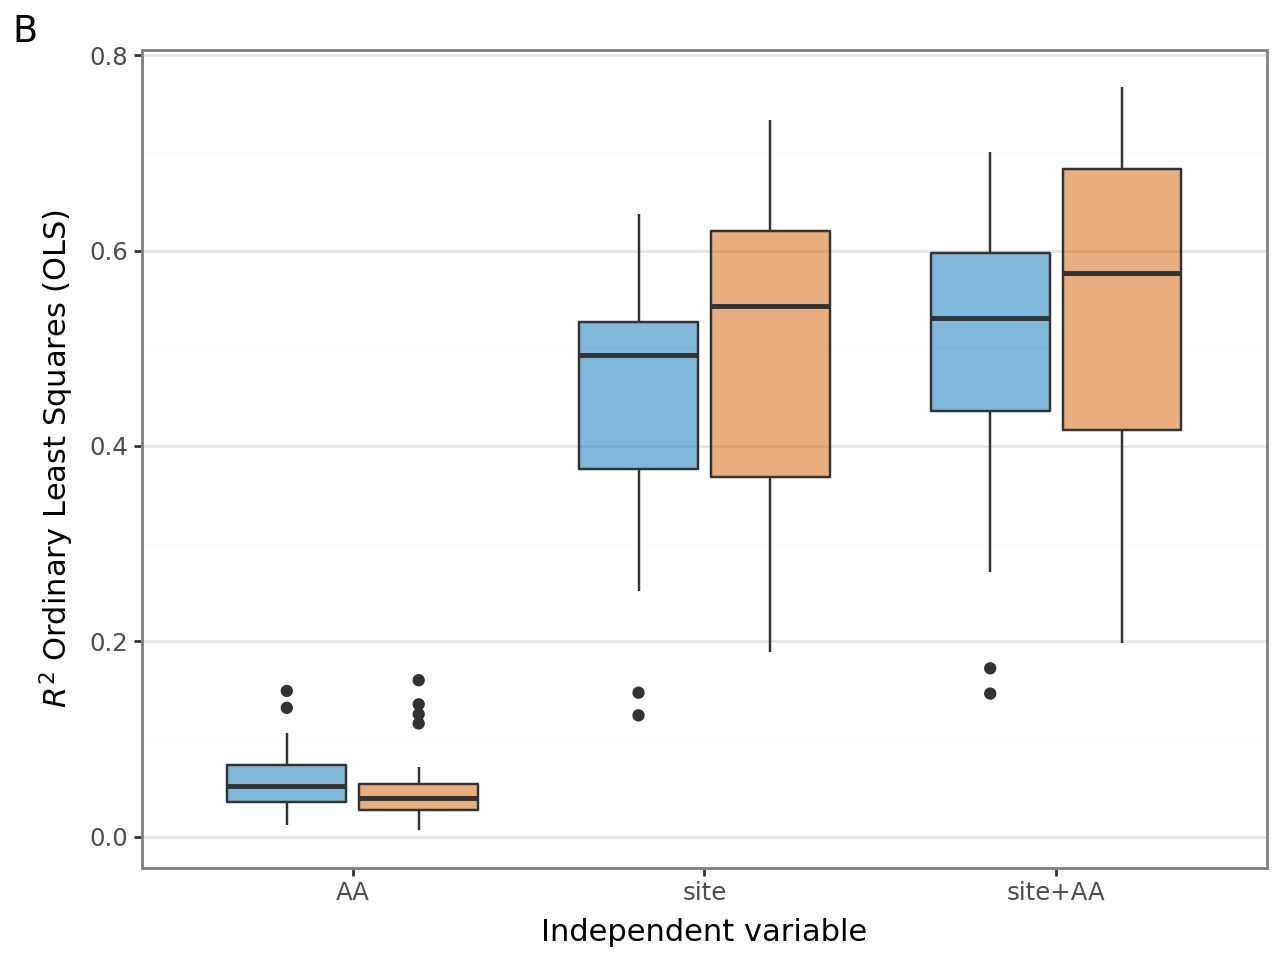

In [19]:
p1 = (
    #pln.ggplot(res_melt, pln.aes(y='R2', x='Source', color='Model'))
    pln.ggplot(res_melt, pln.aes(y='R2', x='Model', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_boxplot(alpha=0.5)
    + pln.theme_bw()
    +pln.labs(
        y='$R^2$ Ordinary Least Squares (OLS)',
        x='Independent variable',
        tag='B')
    + pln.theme(
        #figure_size=(5,4), 
        legend_position='none', 
        panel_grid_major_x=pln.element_blank(), 
        legend_title=pln.element_blank())
    )
    

p1#.save('../experiments/OLS/OLS_site_categorical_source.png', dpi=600)

# AVG vs Transfer Learning

In [4]:
def read_results(res_dir_path, model_name):
    res = pd.DataFrame()
    for file in os.listdir(res_dir_path):
        if file.endswith('.csv'):
            dataset = file.split('.')[0]
            df = pd.read_csv(os.path.join(res_dir_path, file), index_col=0)
            df['Dataset'] = dataset
            res = pd.concat([res, df], ignore_index=True)
    res['Model'] = model_name
    return res

In [5]:
prot_lengths = {}

# viral proteins
for prot in os.listdir('../data/viral/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/viral/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

# non-viral proteins
for prot in os.listdir('../data/cellular/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/cellular/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

## AVG

In [6]:
AVG = pd.DataFrame()
for model in ['AVG']:
    for source in ['viral', 'cellular']:
        for method in ['pool_split']:
            res_dir_path = f'../experiments/{model}/{source}/{method}/'
            res = read_results(res_dir_path, model)
            res['Source'] = source
            res['Split'] = method
            AVG = pd.concat([AVG, res], ignore_index=True)

AVG

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,Dataset,Source,Split
0,AVG,1,0.530925,0.511884,0.683361,0.424830,0.567484,0.765066,0.734405,0.669716,SARS2_PLPRO_abundance_Wu,viral,pool_split
1,AVG,2,0.521827,0.515027,0.691632,0.461210,0.551556,0.732446,0.731561,0.683581,SARS2_PLPRO_abundance_Wu,viral,pool_split
2,AVG,3,0.527835,0.510688,0.683042,0.433635,0.573968,0.768914,0.733999,0.671194,SARS2_PLPRO_abundance_Wu,viral,pool_split
3,AVG,1,0.632854,0.422123,0.603981,0.673508,0.412015,0.578420,0.761273,0.792606,LAMBDA_HCP_Tsuboyama,viral,pool_split
4,AVG,2,0.625207,0.427129,0.611822,0.692847,0.410369,0.553779,0.770798,0.752323,LAMBDA_HCP_Tsuboyama,viral,pool_split
...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,AVG,2,0.263463,0.624286,0.853615,0.186157,0.681182,0.921145,0.471661,0.364794,B3VI55_LIPST_Whitehead2015,cellular,pool_split
218,AVG,3,0.275332,0.623867,0.845470,0.143653,0.690232,0.950018,0.473400,0.347827,B3VI55_LIPST_Whitehead2015,cellular,pool_split
219,AVG,1,0.549891,0.462756,0.676457,0.498551,0.507987,0.684111,0.740102,0.694642,RASH_HUMAN_Kuriyan,cellular,pool_split
220,AVG,2,0.554014,0.466393,0.670008,0.468630,0.499881,0.719181,0.740259,0.688316,RASH_HUMAN_Kuriyan,cellular,pool_split


In [7]:
AGV_grouped = AVG.groupby(['Dataset', 'Source', 'Model', 'Split',], as_index=False)['R2_score_test'].mean()
AGV_grouped

,Dataset,Source,Model,Split,R2_score_test
0,AMIE_PSEAE_Whitehead,cellular,AVG,pool_split,0.405258
1,B3VI55_LIPSTSTABLE,cellular,AVG,pool_split,0.254094
2,B3VI55_LIPST_Whitehead2015,cellular,AVG,pool_split,0.162333
3,BG_STRSQ_hmmerbit,cellular,AVG,pool_split,0.102000
4,BLAT_ECOLX_Ostermeier2014,cellular,AVG,pool_split,0.455095
...,...,...,...,...,...
69,TPK1_HUMAN_Roth2017,cellular,AVG,pool_split,-0.028949
70,TPMT_HUMAN_Fowler2018,cellular,AVG,pool_split,0.229463
71,UBC9_HUMAN_Roth2017,cellular,AVG,pool_split,0.329162
72,UBE4B_MOUSE_Klevit2013_singles,cellular,AVG,pool_split,0.115625


## ESM2 

In [8]:
esm2_lasso = pd.DataFrame()
for model in ['esm2_650M']:
    for source in ['viral', 'cellular']:
        #for method in ['pool_split', 'site_split']:
        for method in ['pool_split']:
            res_dir_path = f'../experiments/lassoCV/{model}/{source}/{method}/'
            res = read_results(res_dir_path, model)
     
            res['Source'] = source
            res['Split'] = method
            esm2_lasso = pd.concat([esm2_lasso , res], ignore_index=True)

esm2_lasso

,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,num_nonzero_coefs,Dataset,Model,Source,Split
0,1,0.567082,0.489658,0.663904,0.506940,0.531408,0.674557,0.762675,0.692692,69,IAV_NA_Jiang,esm2_650M,viral,pool_split
1,2,0.570201,0.469076,0.621080,0.406886,0.721835,0.901440,0.764662,0.636510,56,IAV_NA_Jiang,esm2_650M,viral,pool_split
2,3,0.632405,0.448990,0.602389,0.419914,0.609419,0.776396,0.797082,0.557599,78,IAV_NA_Jiang,esm2_650M,viral,pool_split
3,4,0.647898,0.417984,0.571899,0.320818,0.752558,0.932656,0.816541,0.566546,71,IAV_NA_Jiang,esm2_650M,viral,pool_split
4,5,0.597474,0.470227,0.627029,0.420380,0.637955,0.795527,0.792217,0.552820,66,IAV_NA_Jiang,esm2_650M,viral,pool_split
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365,1,0.773961,0.324683,0.470364,0.597548,0.450427,0.660668,0.752085,0.659438,303,DLG4_RAT_Ranganathan2012,esm2_650M,cellular,pool_split
366,2,0.773265,0.342803,0.490577,0.528302,0.401099,0.590708,0.752106,0.598732,313,DLG4_RAT_Ranganathan2012,esm2_650M,cellular,pool_split
367,3,0.768212,0.331759,0.480795,0.598943,0.435287,0.636679,0.748627,0.652929,320,DLG4_RAT_Ranganathan2012,esm2_650M,cellular,pool_split
368,4,0.763662,0.334612,0.484518,0.610591,0.423895,0.632174,0.755934,0.615004,300,DLG4_RAT_Ranganathan2012,esm2_650M,cellular,pool_split


In [9]:
esm2_lasscv_grouped = esm2_lasso.groupby(['Dataset', 'Source', 'Model', 'Split',], as_index=False)['R2_score_test'].mean()
esm2_lasscv_grouped

,Dataset,Source,Model,Split,R2_score_test
0,AMIE_PSEAE_Whitehead,cellular,esm2_650M,pool_split,0.486188
1,B3VI55_LIPSTSTABLE,cellular,esm2_650M,pool_split,0.468531
2,B3VI55_LIPST_Whitehead2015,cellular,esm2_650M,pool_split,0.256701
3,BG_STRSQ_hmmerbit,cellular,esm2_650M,pool_split,0.427510
4,BLAT_ECOLX_Ostermeier2014,cellular,esm2_650M,pool_split,0.666155
...,...,...,...,...,...
69,TPK1_HUMAN_Roth2017,cellular,esm2_650M,pool_split,0.129374
70,TPMT_HUMAN_Fowler2018,cellular,esm2_650M,pool_split,0.458016
71,UBC9_HUMAN_Roth2017,cellular,esm2_650M,pool_split,0.403438
72,UBE4B_MOUSE_Klevit2013_singles,cellular,esm2_650M,pool_split,0.240093


## Merge

In [10]:
res = pd.concat([esm2_lasscv_grouped, AGV_grouped], axis=0)
res

,Dataset,Source,Model,Split,R2_score_test
0,AMIE_PSEAE_Whitehead,cellular,esm2_650M,pool_split,0.486188
1,B3VI55_LIPSTSTABLE,cellular,esm2_650M,pool_split,0.468531
2,B3VI55_LIPST_Whitehead2015,cellular,esm2_650M,pool_split,0.256701
3,BG_STRSQ_hmmerbit,cellular,esm2_650M,pool_split,0.427510
4,BLAT_ECOLX_Ostermeier2014,cellular,esm2_650M,pool_split,0.666155
...,...,...,...,...,...
69,TPK1_HUMAN_Roth2017,cellular,AVG,pool_split,-0.028949
70,TPMT_HUMAN_Fowler2018,cellular,AVG,pool_split,0.229463
71,UBC9_HUMAN_Roth2017,cellular,AVG,pool_split,0.329162
72,UBE4B_MOUSE_Klevit2013_singles,cellular,AVG,pool_split,0.115625


In [11]:
res_pivot = pd.pivot_table(res, index=['Dataset','Source', 'Split'], columns= 'Model', values='R2_score_test').reset_index()
res_pivot

Model,Dataset,Source,Split,AVG,esm2_650M
0,AMIE_PSEAE_Whitehead,cellular,pool_split,0.405258,0.486188
1,B3VI55_LIPSTSTABLE,cellular,pool_split,0.254094,0.468531
2,B3VI55_LIPST_Whitehead2015,cellular,pool_split,0.162333,0.256701
3,BG_STRSQ_hmmerbit,cellular,pool_split,0.102000,0.427510
4,BLAT_ECOLX_Ostermeier2014,cellular,pool_split,0.455095,0.666155
...,...,...,...,...,...
69,TPK1_HUMAN_Roth2017,cellular,pool_split,-0.028949,0.129374
70,TPMT_HUMAN_Fowler2018,cellular,pool_split,0.229463,0.458016
71,UBC9_HUMAN_Roth2017,cellular,pool_split,0.329162,0.403438
72,UBE4B_MOUSE_Klevit2013_singles,cellular,pool_split,0.115625,0.240093


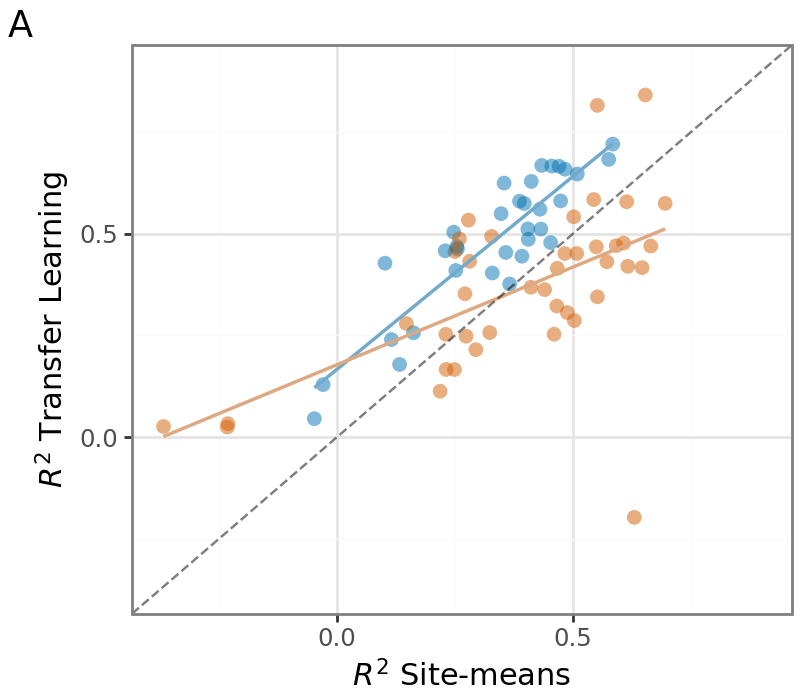

In [19]:
p2 = (
    pln.ggplot(res_pivot, pln.aes(x='AVG', y='esm2_650M', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=3, alpha=0.5, stroke=0)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#DEA880", "cellular": "#72AACB"})
    + pln.theme_bw(11)
    + pln.geom_abline(intercept=0, alpha=0.5, linetype='dashed')
    + pln.theme(
        figure_size=(4,3.5),
        legend_position='none',
        legend_text=pln.element_text(size=11),
        legend_title=pln.element_blank()
    )
    + pln.xlim(-0.37, 0.9)
    + pln.ylim(-0.37, 0.9)

    + pln.labs(
        y="$R^2$ Transfer Learning",
        x="$R^2$ Site-means",
        tag='A'
    )
    )
p2

# Composition

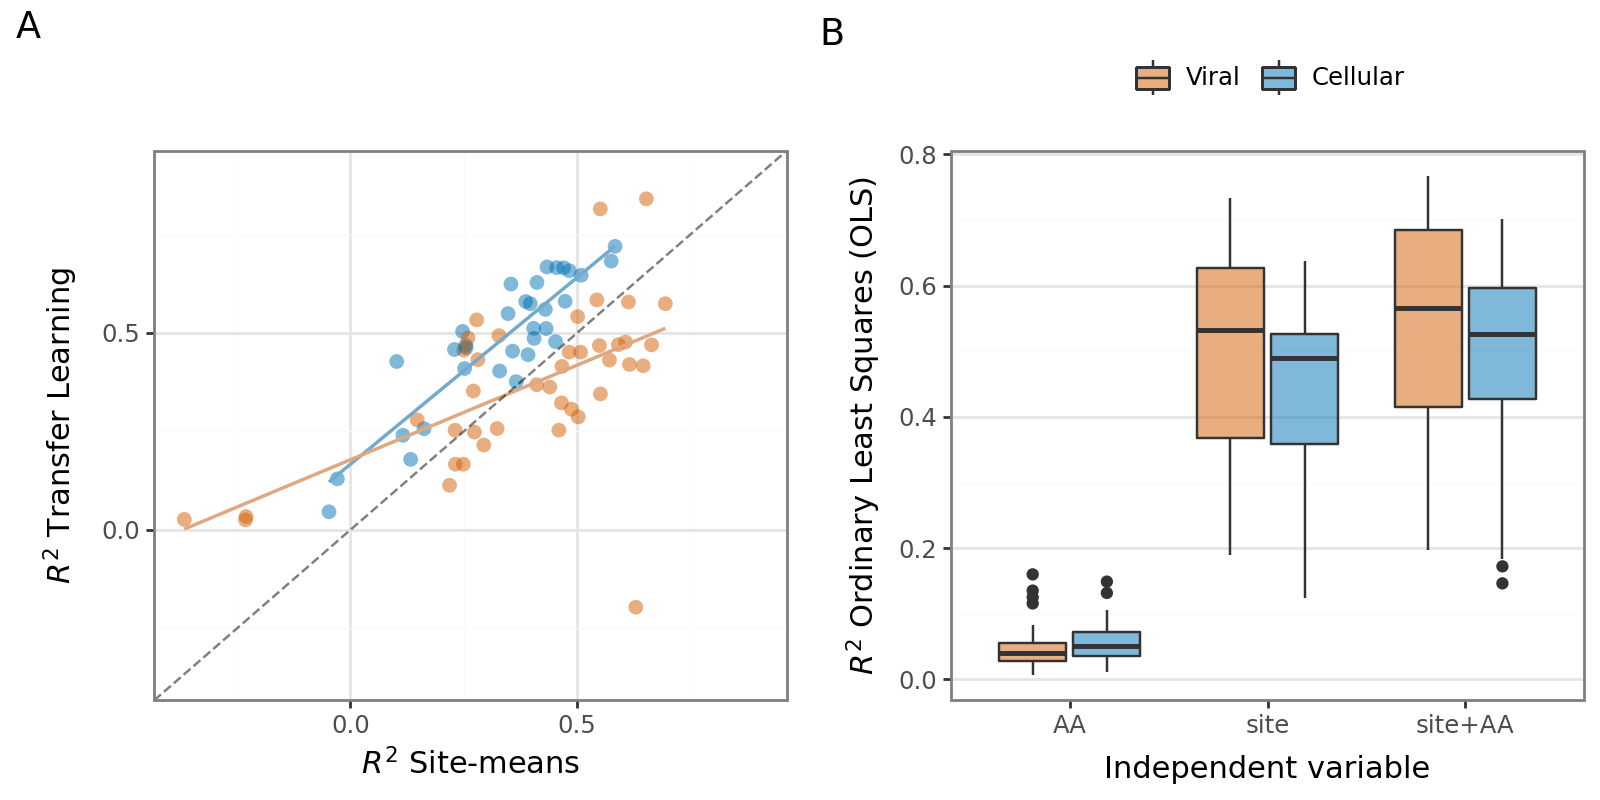

In [20]:
comp = p2 | p1
plot = comp + pln.theme(figure_size=(8, 4), legend_position='top')
plot.save(filename='../experiments/figures/comp2_lassoCV_x_AVG.png', dpi=600)
plot